### Agentic RAG

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["GEMINI_API_KEY"]=os.getenv("GEMINI_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader,RecursiveUrlLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

c:\Users\varke\OneDrive\Desktop\GENAI\LangGraph_Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/map-reduce"
]

docs = []

for url in urls:
    loader = WebBaseLoader(url)
    docs.extend(loader.load())

print(docs[0].page_content[:1000])

LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionFault toleranceStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCore benefitsLangGraph ecosystemAcknowledgementsLangGraph overviewCopy pageGain control with LangGraph to design agents that reliably handle complex tasksCopy pageDocumentation IndexFetch the complete documentation index at: https://docs

In [4]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)

vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

retriever = vectorstore.as_retriever()

C:\Users\varke\AppData\Local\Temp\ipykernel_9192\3808706045.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6538.61it/s]


In [5]:
retriever.invoke("What is LangGraph?")

[Document(id='3450593a-f3af-4dc8-a806-9672e9f35784', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='reliably handle complex tasksCopy pageDocumentation IndexFetch the complete documentation index at: https://docs.langchain.com/llms.txtUse this file to discover all available pages before exploring further.Trusted by companies shaping the future of agents— including Klarna, Uber, J.P. Morgan, and more— LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents.'),
 Document(id='0d17f7c7-177c-4c83-8ae5-401a999ed5ab', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents tha

In [6]:
### Retriever To Retriever Tools
from langchain_core.tools import create_retriever_tool
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [7]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001ACDF18E350>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001ACDDD440F0>)

### Langchain Blogs- Seperate Vector Store


In [8]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs = []

for url in langchain_urls:
    loader = WebBaseLoader(url)
    docs.extend(loader.load())

print(docs[0].page_content[:1000])

LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy with LangSmithDeploymentObservabilityOn this page Create an agent Core benefitsLangChain overviewCopy pageLangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents

In [9]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)

vectorstoreLangchain = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

retrieverLangchain = vectorstoreLangchain.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6367.51it/s]


In [10]:
retrieverLangchain.invoke("What is LangChain?")

[Document(id='64ab22e9-4928-48eb-8adf-3acfe3900fd7', metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRu

In [11]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverLangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [12]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [13]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

c:\Users\varke\OneDrive\Desktop\GENAI\LangGraph_Basics\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [14]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
llm.invoke("Hi")

AIMessage(content='<think>\nOkay, the user just said "Hi". I need to respond appropriately. Since it\'s a greeting, I should acknowledge it and offer assistance. Let me check the guidelines. I should keep it friendly and open-ended. Maybe say something like "Hello! How can I assist you today?" That should work. Let me make sure there\'s no need for further action. The user might have a specific request, so keeping the response welcoming is key. Alright, that\'s ready to send.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 9, 'total_tokens': 123, 'completion_time': 0.220689133, 'completion_tokens_details': None, 'prompt_time': 0.000360747, 'prompt_tokens_details': None, 'queue_time': 0.054150703, 'total_time': 0.22104988}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'g

In [15]:
#Agent node
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen/qwen3-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [16]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

In [17]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3-32b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [18]:
prompt = ChatPromptTemplate.from_template(
    """
You are a helpful AI assistant for question-answering tasks.

Use the following retrieved context to answer the question.

If you don't know the answer, say you don't know.

Question:
{question}

Context:
{context}

Answer:
"""
)

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

rag_chain = prompt | llm | StrOutputParser()


def generate(state):

    print("---GENERATE---")

    messages = state["messages"]

    question = messages[0].content

    docs = messages[-1].content

    response = rag_chain.invoke({
        "question": question,
        "context": docs
    })

    return {
        "messages": [response]
    }

In [19]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="llama-3.3-70b-versatile")
    response = model.invoke(msg)
    return {"messages": [response]}

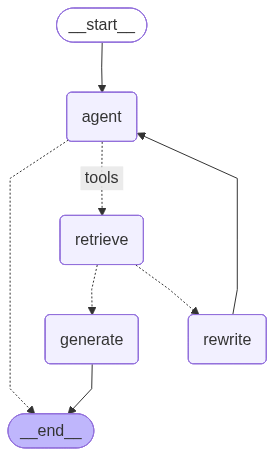

In [20]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [21]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='cb765de8-c361-4ea9-98a9-628735e0ca17'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is Langgraph?" Let me figure out how to approach this.\n\nFirst, I need to check the available tools. There\'s a function called retriever_vector_db_blog which is for searching information about Langgraph. Since the user is asking about Langgraph specifically, that\'s the tool I should use. The other tool is for Langchain, which might be related but not exactly what\'s needed here.\n\nThe function requires a query parameter. The user\'s question is straightforward, so the query should be "What is Langgraph?" I\'ll structure the tool call with that query. I need to make sure the JSON is correctly formatted with the function name and arguments. Let me double-check the parameters to avoid any syntax errors. Alright, that should do it.\n', 'tool_calls'

In [22]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='b78e93fa-c998-40f3-9d31-78115a557799'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is Langchain?" Let me figure out how to respond.\n\nFirst, I need to determine which tool to use. The available tools are for searching information about Langgraph and Langchain. Since the question is about Langchain, the appropriate function is "retriever_vector_langchain_blog". \n\nThe function requires a query parameter. The user\'s query is straightforward, so I\'ll use "What is Langchain?" as the query. I should structure the tool call with the function name and the query as arguments. \n\nI need to make sure the JSON is correctly formatted, with the function name and arguments. No other functions are needed here. Let me double-check the parameters to ensure they\'re correct. Yes, the query is properly specified. Alright, that should do it.\n'

In [23]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='7be06ec2-6c82-4fb4-82ff-5467ce103d09'),
  AIMessage(content='The question "What is Machine Learning?" is a general conceptual query rather than one requiring specific information retrieval about Langgraph or Langchain. Since the provided tools are designed for project-specific searches, I\'ll answer based on my existing knowledge.\n\nMachine Learning (ML) is a subset of artificial intelligence that enables computer systems to learn from data and improve performance on specific tasks over time without being explicitly programmed. It involves developing algorithms that can identify patterns in data, make predictions, or take actions based on those patterns. Common techniques include supervised learning (e.g., classification, regression), unsupervised learning (e.g., clustering), and reinforcement learning.\n\nKey applications include image recognition, natural language processi

In [24]:
graph.invoke({"messages":"How to use langgraph nodes with AWS?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='How to use langgraph nodes with AWS?', additional_kwargs={}, response_metadata={}, id='ab5dc7bf-5393-4cba-bb2f-3f9dc9b36050'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking how to use Langgraph nodes with AWS. Let me break this down.\n\nFirst, I need to understand what Langgraph is. From the tools provided, there\'s a function called retriever_vector_db_blog which is for searching information about Langgraph. So maybe I should use that to find relevant info.\n\nThe user wants to integrate Langgraph nodes into an AWS environment. AWS has various services like Lambda, EC2, S3, etc. So the answer might involve deploying Langgraph nodes on AWS infrastructure. But I need specific steps or guides.\n\nSince I have access to the retriever_vector_db_blog function, I should query it with the user\'s question. The function\'s parameters require a query string. Let me input "How to use langgraph nodes with AWS?" into t